# Группа №28

# Описание экспериментов

### В ходе работы было проведено множество экспериментов различного рода, начиная от способов аугментации, борьбы с дисбалансом классов, заканчивая различным инференсом и подбором порога(threshold). Подробнее про некоторые из них:

* #### 1. Самый первый эксперимент был взят как бейзлайн, от которого и будет высчитываться дальнейшая прибавка. В целом пайплайн схож с тем, что был предложен в 4 дз семинара по задачам КЗ, то есть это небольшая аугментация обучающих данных(rotation+flip), `CrossEntropy` в качестве функции потерь, и параметр функции `weights` использовался для борьбы с дисбалансом классов, архитектура модели была `CNN` + `resblocks`, также в каждом подходе использовался `scheduler` и `earlystopping`, как одни из методов борьбы с переобучением. В конечном итоге такая модель показала результат в ~ `88%`.

* #### 2. Идея для следующего эксперимента была попыткой скормить выход нашей сети таким моделям как `RandomForest`, `CatBoost`, `XgBoost`,c последующим подбором гиперпараметров через `RandomisedCearchCV` к сожалению, результаты не стали лучше, остались в районе ~ `87-88%`.

* #### 3. Данный эксперимент обусловлен желанием понять насколько высокий скор можно получить из обычной `CNN` без использования различного рода слоёв, специализирующихся на обработке шахматных артефактов. Было добавлено больше слоёв и параметров модели, также теперь использовался другой подход к борьбе с дисбалансом классов, а именно `WeightedRandomSampler`, в последующем он будет везде, тк результаты с ним лучше. Было измнено кол-во эпох для остановки `EarlyStopping`, давая модели больше возможностей для нахождения новых минимумов, и была усилена аугментации с целью борьбы с переобучением(`ColorJlitter`, `GrayScale`). Такая модель показала результат в ~ `92%`, что прирост в 3-4% от бейзлайна.

  

### Последующие попытки усовершенствовать обычную сверточную сеть не увенчались успехами, результаты были или хуже или такими же. Поэтому концептуальный подход был изменён в сторону специальных слоёв, способных улавливать шахматные артефакты, которые оставляет `StyleGan`

  

* #### 1. Первый эксперимент с новыми архитектурами не увенчался успехами, была выбрана архитектура с `SRM` необучаемыми слоями(фильтры извлекающие шум), идея была в том, чтобы пытаться детектить фейки не по геометрическим признакам(контуры, линии и тд), а по шуму, который оставляет `StyleGan`. Важно было убрать некоторую аугментацию, чтобы шум не размывался(`ColorJlitter`). В конечном итоге такая модель показала результат в ~ `84%`, что ниже бейзлайна на 4%.

* #### 2. Оставлять идею архитектуры, работающей с шумом не хотелось, поэтому предпринимались различные попытки добавления своеобразных механизмов внимания, `resblocks`, но результат оставался все равно ниже бейзлайна. Переломным моментом стала попытка образовать двухголовую нейросеть, одна голова будет работать с шумом при помощи `SRM` слоёв, вторая же будет обычной `CNN`, результат будет просто конкатенироваться из двух голов, и пропускаться через полносвязный слой. Такой подход дал огромный прирост и спустя ~ 40 эпох, получилось достигнуть `val_f1 = 94.41%`, что дало аж ~6% от бейзлайна. Здесь начал использоваться интересный механизм `TTA`, его суть заключается в том, что теперь мы берем не только одну тестовую картинку,а 9-12(каждая из них меняется, или размер, или поворот, или флип), делаем инференс и усредняем вероятность, такой подход позволяет получить больший скор за счёт особенности `SRM` слоёв, часть шума лучше улавливалась на картинках большего масштаба.

* #### 3. Дальнейший довольно большой промежуток времени тратился на попытки изменить аугментацию, добавить слоёв/параметров, искать новый `threshold`, менять `TTA`, в конечном итоге модель упёрлась в потолок ~ `95.7%`.


### Следующий довольно большой промежуток времени был потрачен на следующую идею: возьмём, обучим много больших моделей ~ `95-96%` % и создадим из них ансамбль, с целью получить высший скор. Для этого создавались различные архитектуры, комбинируя уже вышеперечисленные слои, и в конечном итоге результат остался тем же, видимо ошибки этих моделей коррелируют(идея была в том, что одна модель поможет перекрыть ошибки другой, но так не вышло). Поэтому вернулись к нашей архитектуре с `SRM` слоями.


* #### 1. После довольно долгого простоя на отметке в `95-96%` было предложено усовершенствовать уже имеющуюся архитектуру следующим образом: Добавим обучающую шумовую ветку, напомню что `SRM` слои были просто статичными фильтрами, а слой `BayarConv2d`: использует сверточный слой со специальным ограничением (сумма весов равна 0, значение в центре принудительно равно -1). Данный фильтр подавляет визуальный контент и выделяет высокочастотный шум и локальные артефакты склейки пикселей. А также изменим функцию потерь с `CrossEntropy` на `FocalLoss`, чтобы фокусироваться на трудных примерах. Такой подход дал лучший результат в `~97%`, что уже 9% от бейзлайна.
  
* #### 2. И последние финальные эксперименты это лучшее, что получилось у нас, за основу была взята всё та же модель, но теперь она стала 3-х головой, добавилось разложение в ряды Фурье, и теперь результат не просто конкатенируется, и также был добавлен особый метод аугментации `CutMix`. Подробнее это будет описано ниже, не буду повторяться. Такой подход позволил нам получить рекордные `98.951%` и главное, `loss=0.0051`, что делает нашу модель невероятно устойчивой, это позволяет нам быть уверенным в нашем результате и не бояться сильно улететь вниз, при открытии приватного борда.

# Основная часть

### Импорт нужных библиотек

In [42]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import random
from torch.utils.data import DataLoader, random_split, Dataset
import matplotlib.pyplot as plt
from IPython.display import clear_output
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from torchinfo import summary
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import os
from PIL import Image
from sklearn.metrics import f1_score
from torch.utils.data import WeightedRandomSampler
from torchvision.transforms.functional import to_tensor

### Класс кастомного датасета

In [39]:
class KaggleDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx, 0]
        label = self.df.iloc[idx, 1]
        img_path = os.path.join(self.img_dir, img_name)
        
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

### Считаем mean/std на обучающей выборке, избегая утечку данных

In [45]:
img_dir = 'dataset/train_images/'
files = [os.path.join(img_dir, f) for f in os.listdir(img_dir) if f.endswith('.jpg')]

mean = torch.zeros(3)
sq_mean = torch.zeros(3)
n = len(files)

for f in files:
    img = to_tensor(Image.open(f).convert('RGB')).view(3, -1)
    mean += img.mean(1)
    sq_mean += (img ** 2).mean(1)

dataset_mean = mean / n
dataset_std = torch.sqrt(sq_mean / n - dataset_mean ** 2)

print(dataset_mean.tolist())
print(dataset_std.tolist())

[0.5191540122032166, 0.42761602997779846, 0.3843510150909424]
[0.2859744429588318, 0.2640231251716614, 0.26352086663246155]


### Делим трейн на трейн/валидацию

In [8]:
train_df = pd.read_csv('dataset/train_solution.csv', header=None)
train_df.iloc[:, 0] = train_df.iloc[:, 0].astype(str)
if not train_df.iloc[0, 0].endswith('.jpg'):
    train_df.iloc[:, 0] = train_df.iloc[:, 0].apply(lambda x: f"{x}.jpg")
train_data, val_data = train_test_split(
    train_df, 
    test_size=0.1, 
    random_state=42,
    stratify = train_df.iloc[:,1]
)
img_dir = 'dataset/train_images/'

C:\Users\Леша\AppData\Local\Temp\ipykernel_26384\2853660237.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0            0
1            1
2            2
3            3
4            4
         ...  
49995    49995
49996    49996
49997    49997
49998    49998
49999    49999
Name: 0, Length: 50000, dtype: object' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train_df.iloc[:, 0] = train_df.iloc[:, 0].astype(str)


### Видим дисбаланс классов ~(5/1)

In [9]:
print(train_df.iloc[:, 1].value_counts(normalize=True))

1
0    0.83
1    0.17
Name: proportion, dtype: float64


### Используем  `WeightedRandomSampler` чтобы сэмплы минаритарного класса чаще попадали в `DataLoader`

In [10]:
target = train_data.iloc[:, 1].values
class_sample_count = np.array([len(np.where(target == t)[0]) for t in np.unique(target)])
weight = 1. / class_sample_count
samples_weight = np.array([weight[t] for t in target])
samples_weight = torch.from_numpy(samples_weight)

sampler = WeightedRandomSampler(samples_weight.type('torch.DoubleTensor'), len(samples_weight))

### Формируем `DataLoader`, отдельно прописываем трансформеры для трейна(делаем аугментацию) и валидации/теста. 

In [11]:
BATCH_SIZE=16
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(256, scale=(0.9, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),   
    transforms.RandomRotation(15),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5191555023193359, 0.42761698365211487, 0.3843500316143036], std=[0.25871002674102783, 0.23721903562545776, 0.23342262208461761])
])
val_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5191555023193359, 0.42761698365211487, 0.3843500316143036], std=[0.25871002674102783, 0.23721903562545776, 0.23342262208461761])
])
train_ds = KaggleDataset(train_data, img_dir, train_transforms)
val_ds = KaggleDataset(val_data, img_dir, val_transforms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, sampler=sampler)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

### Класс ранней остановки делаем с целью избежания переобучения и фиксации лучших параметров сети

In [12]:
class EarlyStopping:
    def __init__(self, patience=7, verbose=False, delta=0, path='kaggle8.pth'):
        self.patience = patience    
        self.verbose = verbose      
        self.counter = 0           
        self.best_score = None      
        self.early_stop = False     
        self.val_loss_min = np.inf  
        self.delta = delta          
        self.path = path           

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

### Некоторые особенности аугментации и использование неочевидной функции потерь

* CutMix аугментация: Во время обучения формируются изображения путем вырезания случайного прямоугольного фрагмента из одной картинки батча и вставки его в другую. Метки классов смешиваются пропорционально площади фрагмента. Это заставляет модель искать признаки подделки по всему полю кадра, а не заучивать конкретные детали.
  
* Focal Loss заставляет модель фокусироваться на трудных примерах, на которых она ошибается, и игнорировать те, что уже хорошо выучены:

  
   * 1.Гамма ($\gamma = 2.0$): Параметр фокусировки. Чем он выше, тем сильнее модель игнорирует простые примеры и вгрызается в сложные.
     
   * 2.Альфа ($\alpha = 0.75$): Весовой коэффициент, который дополнительно помогает сбалансировать классы, отдавая приоритет миноритарному классу сгенерированных изображений.

In [13]:
import torch.nn.functional as F
import numpy as np

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

def rand_bbox(size, lam):
    W = size[2]
    H = size[3]
    cut_rat = np.sqrt(1. - lam)
    cut_w = int(W * cut_rat)
    cut_h = int(H * cut_rat)

    cx = np.random.randint(W)
    cy = np.random.randint(H)

    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)

    return bbx1, bby1, bbx2, bby2

### Пайплайн обучения

* Оптимизация: Обучение проводится с использованием AdamW (learning_rate = 1e-4, weight_decay = 0.05).

* Планировщик: ReduceLROnPlateau (factor=0.5, patience=3) обеспечивает тонкую доводку весов при достижении плато на функции потерь.

* Mixed Precision: Для увеличения скорости обучения и снижения потребления VRAM используется torch.amp.autocast('cuda') с GradScaler.

* Early Stopping: Внедрен алгоритм ранней остановки (patience=10, delta=0.0005), который сохраняет чекпоинт в точке абсолютного минимума Val Loss.

In [14]:
from torch.cuda.amp import autocast, GradScaler

def train(model, optimizer, epochs=60):
    scaler = torch.amp.GradScaler('cuda')
    beta = 1.0 
    cutmix_prob = 0.5

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        all_train_preds = [] 
        all_train_labels = []

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1} Train")
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device).long()
            optimizer.zero_grad()

            r = np.random.rand(1)
            
            if beta > 0 and r < cutmix_prob:
                lam = np.random.beta(beta, beta)
                rand_index = torch.randperm(images.size()[0]).to(device)
                
                target_a = labels
                target_b = labels[rand_index]
                
                bbx1, bby1, bbx2, bby2 = rand_bbox(images.size(), lam)
                images[:, :, bbx1:bbx2, bby1:bby2] = images[rand_index, :, bbx1:bbx2, bby1:bby2]
                
                lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (images.size()[-1] * images.size()[-2]))
                
                with torch.amp.autocast('cuda'):
                    outputs = model(images)
                    loss = criterion(outputs, target_a) * lam + criterion(outputs, target_b) * (1. - lam)
            
            else:
               with torch.amp.autocast('cuda'):
                    outputs = model(images)
                    loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, 1)
            all_train_preds.extend(predicted.cpu().numpy())
            all_train_labels.extend(labels.cpu().numpy())
            
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        train_f1 = f1_score(all_train_labels, all_train_preds, average='macro')
        
        model.eval()
        val_loss = 0
        all_val_preds = []
        all_val_labels = []
        
        with torch.no_grad(): 
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device).long()
                
                with autocast():
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                all_val_preds.extend(predicted.cpu().numpy())
                all_val_labels.extend(labels.cpu().numpy())

        val_f1 = f1_score(all_val_labels, all_val_preds, average='macro')
        
        train_loss_avg = train_loss / len(train_loader)
        val_loss_avg = val_loss / len(val_loader)
        scheduler.step(val_loss_avg)
        
        history['train_loss'].append(train_loss_avg)
        history['val_loss'].append(val_loss_avg)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)

        early_stopping(val_loss_avg, model)
        
        clear_output(wait=True)
        plt.figure(figsize=(12, 5))
        
        plt.subplot(1, 2, 1)
        plt.plot(history['train_loss'], label='Train Loss')
        plt.plot(history['val_loss'], label='Val Loss')
        plt.title(f'Epoch {epoch+1} Loss')
        plt.legend()
        
        plt.subplot(1, 2, 2)
        plt.plot(history['train_f1'], label='Train F1')
        plt.plot(history['val_f1'], label='Val F1')
        plt.title(f'Epoch {epoch+1} F1 Score')
        plt.legend()
        
        plt.show()
        print(f"Epoch {epoch+1}: Train Loss {train_loss_avg:.4f}, Train F1 {train_f1:.4f}, Val Loss {val_loss_avg:.4f}, Val F1 {val_f1:.4f}")

        if early_stopping.early_stop:
            print("Early stopping triggered")
            break

## Архитектура Модели

* Пространственная ветка (RGB): Принимает исходное изображение и извлекает стандартные семантические и геометрические формы.
  
* Шумовая ветка (BayarConv2d): Использует сверточный слой со специальным ограничением (сумма весов равна 0, значение в центре принудительно равно -1). Данный фильтр подавляет визуальный контент и выделяет высокочастотный шум и локальные артефакты склейки пикселей.

* Частотная ветка (FFT): Применяет двумерное быстрое преобразование Фурье, извлекая магнитуду спектра в логарифмическом масштабе. StyleGAN оставляет специфические следы  в частотной области, которые эффективно улавливаются этим потоком.

* Механизм внимания (SEResNeXtBottleneck): В качестве блока используется модифицированный слой ResNeXt с добавлением Squeeze-and-Excitation. Механизм внимания позволяет сети динамически фокусироваться на наиболее информативных каналах, отсекая лишний шум.

* Поэтапное слияние (FusionBlockTitan): Признаки из трех веток не просто конкатенируются в конце, а объединяются через слои 1x1 Conv + BatchNorm + ReLU на четырех различных уровнях глубины. Это позволяет сети находить корреляции между частотными и пространственными аномалиями на разных разрешениях.

In [15]:
import torch.fft
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.squeeze = nn.AdaptiveAvgPool2d(1)
        self.excitation = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.squeeze(x).view(b, c)
        y = self.excitation(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class SEResNeXtBottleneckTitan(nn.Module):
    expansion = 4
    def __init__(self, in_channels, out_channels, stride=1, groups=32, width_per_group=4):
        super().__init__()
        width = int(out_channels * (width_per_group / 64.)) * groups
        
        self.conv1 = nn.Conv2d(in_channels, width, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(width)
        self.conv2 = nn.Conv2d(width, width, kernel_size=3, stride=stride, padding=1, groups=groups, bias=False)
        self.bn2 = nn.BatchNorm2d(width)
        self.conv3 = nn.Conv2d(width, out_channels * self.expansion, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)
        self.relu = nn.ReLU(inplace=True)
        self.se = SEBlock(out_channels * self.expansion)
        
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels * self.expansion:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels * self.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * self.expansion)
            )

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        out = self.se(out)
        out += identity
        return self.relu(out)

class BayarConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=5, stride=1, padding=2):
        super(BayarConv2d, self).__init__()
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding
        self.kernel = nn.Parameter(torch.empty(out_channels, in_channels, kernel_size, kernel_size))
        nn.init.kaiming_normal_(self.kernel)

    def forward(self, x):
        mask = torch.ones_like(self.kernel)
        mask[:, :, self.kernel_size // 2, self.kernel_size // 2] = 0
        w = self.kernel * mask
        w_sum = w.sum(dim=(2, 3), keepdim=True)
        w = w / (w_sum + 1e-8)
        final_kernel = w - (1 - mask) 
        return torch.nn.functional.conv2d(x, final_kernel, stride=self.stride, padding=self.padding)
        
class FusionBlockTitan(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.mixer = nn.Sequential(
            nn.Conv2d(dim * 3, dim, kernel_size=1, bias=False),
            nn.BatchNorm2d(dim),
            nn.ReLU(inplace=True)
        )
    def forward(self, r, n, f):
        return self.mixer(torch.cat([r, n, f], dim=1))

class StyleGanTitanNet(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.bayar = BayarConv2d(3, 3) 

        self.rgb_init = self._make_stem(3, 64)
        self.noise_init = self._make_stem(3, 64)
        self.fft_init = self._make_stem(3, 64)

        self.layer1_rgb = self._make_layer(64, 64, 3)
        self.layer1_noise = self._make_layer(64, 64, 3)
        self.layer1_fft = self._make_layer(64, 64, 3)
        self.fusion1 = FusionBlockTitan(256) # 64 * 4

        self.layer2_rgb = self._make_layer(256, 128, 4, stride=2)
        self.layer2_noise = self._make_layer(256, 128, 4, stride=2)
        self.layer2_fft = self._make_layer(256, 128, 4, stride=2)
        self.fusion2 = FusionBlockTitan(512) # 128 * 4

        self.layer3_rgb = self._make_layer(512, 256, 6, stride=2)
        self.layer3_noise = self._make_layer(512, 256, 6, stride=2)
        self.layer3_fft = self._make_layer(512, 256, 6, stride=2)
        self.fusion3 = FusionBlockTitan(1024) # 256 * 4

        self.layer4_rgb = self._make_layer(1024, 512, 3, stride=2)
        self.layer4_noise = self._make_layer(1024, 512, 3, stride=2)
        self.layer4_fft = self._make_layer(1024, 512, 3, stride=2)
        self.fusion4 = FusionBlockTitan(2048) # 512 * 4

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(2048, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def _make_stem(self, in_c, out_c):
        return nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(out_c), nn.ReLU(inplace=True), nn.MaxPool2d(3, 2, 1)
        )

    def _make_layer(self, in_c, out_c, blocks, stride=1):
        layers = []
        layers.append(SEResNeXtBottleneckTitan(in_c, out_c, stride))
        for _ in range(1, blocks):
            layers.append(SEResNeXtBottleneckTitan(out_c * 4, out_c))
        return nn.Sequential(*layers)

    def extract_fft_magnitude(self, x):
        fft_mag = torch.abs(torch.fft.fft2(x, norm="forward"))
        fft_mag = torch.fft.fftshift(fft_mag, dim=(-2, -1))
        return torch.log1p(fft_mag)

    def forward(self, x):
        r, n, f_in = self.rgb_init(x), self.noise_init(self.bayar(x)), self.fft_init(self.extract_fft_magnitude(x))
        
        m1 = self.fusion1(self.layer1_rgb(r), self.layer1_noise(n), self.layer1_fft(f_in))
        m2 = self.fusion2(self.layer2_rgb(m1), self.layer2_noise(m1), self.layer2_fft(m1))
        m3 = self.fusion3(self.layer3_rgb(m2), self.layer3_noise(m2), self.layer3_fft(m2))
        m4 = self.fusion4(self.layer4_rgb(m3), self.layer4_noise(m3), self.layer4_fft(m3))
        
        return self.fc(self.pool(m4))

In [16]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"device: {device}")

device: cuda


In [17]:
def init_weights(m):
    if isinstance(m, nn.Conv2d) and m.weight.requires_grad:
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
model = StyleGanTitanNet(num_classes=2).to(device)
model.apply(init_weights) 
criterion = FocalLoss().to(device)
optimizer = optim.AdamW(model.parameters(), lr = 1e-4,weight_decay=0.05)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5,threshold = 0.0001)
summary(model, input_size=(BATCH_SIZE,3,256,256))

Layer (type:depth-idx)                        Output Shape              Param #
StyleGanTitanNet                              [16, 2]                   --
├─Sequential: 1-1                             [16, 64, 64, 64]          --
│    └─Conv2d: 2-1                            [16, 64, 128, 128]        9,408
│    └─BatchNorm2d: 2-2                       [16, 64, 128, 128]        128
│    └─ReLU: 2-3                              [16, 64, 128, 128]        --
│    └─MaxPool2d: 2-4                         [16, 64, 64, 64]          --
├─BayarConv2d: 1-2                            [16, 3, 256, 256]         225
├─Sequential: 1-3                             [16, 64, 64, 64]          --
│    └─Conv2d: 2-5                            [16, 64, 128, 128]        9,408
│    └─BatchNorm2d: 2-6                       [16, 64, 128, 128]        128
│    └─ReLU: 2-7                              [16, 64, 128, 128]        --
│    └─MaxPool2d: 2-8                         [16, 64, 64, 64]          --
├─Sequentia

### Ниже представлен процесс обучения:
* #### Первый график обучения представляет полное обучение модели с нуля, видим постепенный рост `f1` и срабатывание ранней остановки на 48 эпохе
* #### Второй график уже предсатвляет попытку дожать модель до лучшего результата за 40 эпох ранняя остановка так и не сработала, что позволяет сделать еще 3 цикл дообучения
* #### Ну и третий график это попытка выгрызть сотые процента при этом не переобучая модель, что позволило получить минимальный лосс на валидации и высочайший `f1`

* 1-ый этап обучения: `loss`=0.01, 'f1_val'=0.9773
* 2-ой этап обучения: `loss`=0.0067 'f1_val'=0.9818
* 3-ий этап обучения: `loss`=0.0053 'f1_val'=0.9868

Модель оказалась очень устойчивой к переобучению и постоянно находила лучший `loss`, это позволяет сильная аугментация обучающей выборки + сильная архитектура с 

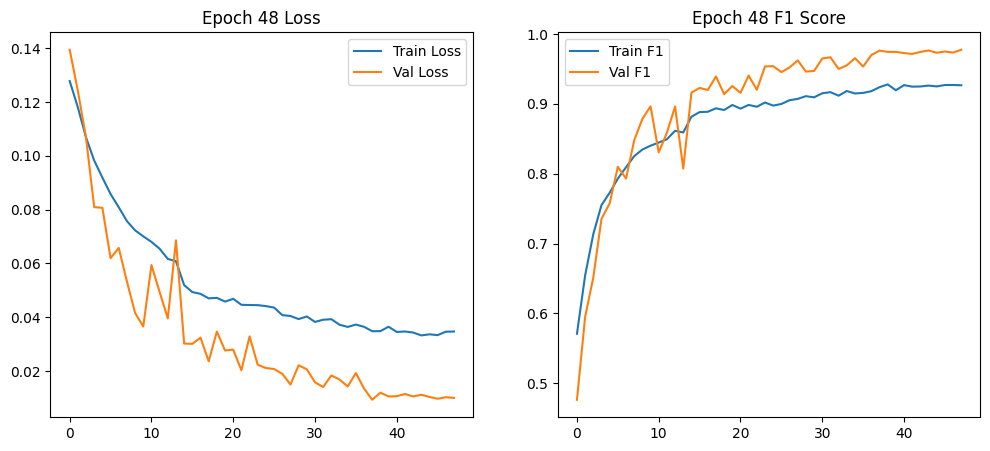

Epoch 48: Train Loss 0.0347, Train F1 0.9266, Val Loss 0.0100, Val F1 0.9773
Early stopping triggered


In [13]:
history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
early_stopping = EarlyStopping(patience=10,verbose=True,delta = 0.0005)
train(model,optimizer,epochs=60)

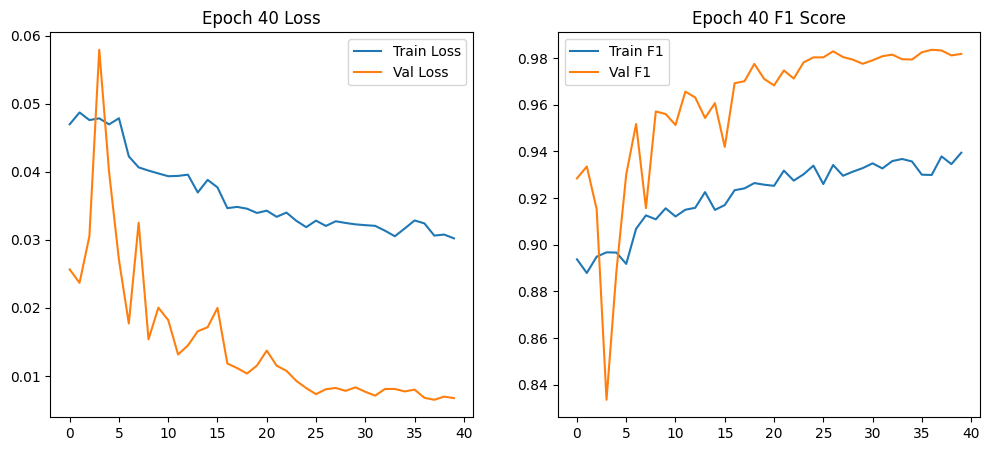

Epoch 40: Train Loss 0.0302, Train F1 0.9395, Val Loss 0.0067, Val F1 0.9818


In [20]:
model.load_state_dict(torch.load('kaggle8.pth'))

history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
optimizer = optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.05)

criterion = FocalLoss().to(device)
optimizer = optim.AdamW(model.parameters(), lr = 1e-4,weight_decay=0.05)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5,threshold = 0.0001)

early_stopping = EarlyStopping(patience=15, verbose=True, path='Kaggle8_final.pth')

train(model, optimizer, epochs=40)

#### Внизу не ошибка, это ручное прерывание обучения, тк модель топталась на месте, это подтверждает сообщение снизу `KeyboardInterrupt:`

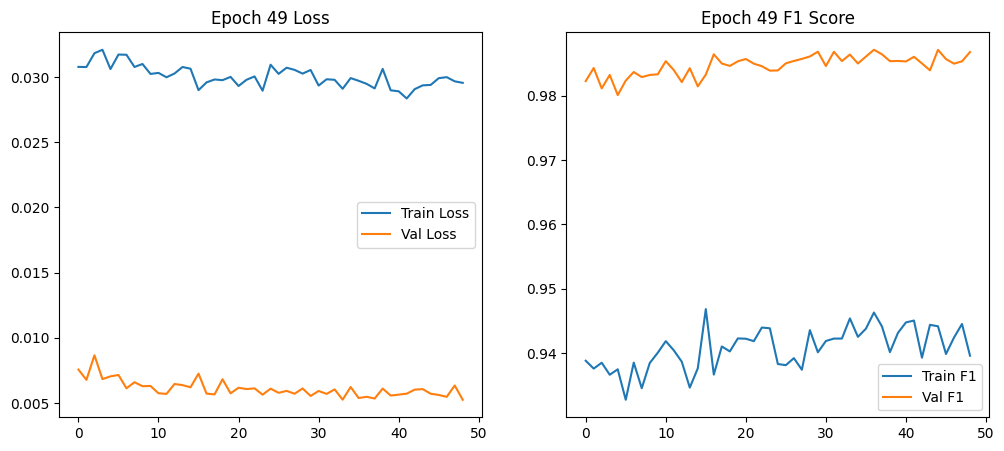

Epoch 49: Train Loss 0.0296, Train F1 0.9396, Val Loss 0.0053, Val F1 0.9868


Epoch 50 Train:   6%|██▊                                               | 161/2813 [01:08<18:54,  2.34it/s, loss=0.0907]


KeyboardInterrupt: 

In [22]:
model.load_state_dict(torch.load('Kaggle8_final.pth'))

history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}

criterion = FocalLoss().to(device)
optimizer = optim.AdamW(model.parameters(), lr = 1e-5,weight_decay=0.05)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5,threshold = 0.0001)

early_stopping = EarlyStopping(patience=15, verbose=True, path='Kaggle8_final_final.pth')

train(model, optimizer, epochs=70)

### Пытаемся найти оптимальный порог(threshold)

In [32]:
model.load_state_dict(torch.load('Kaggle8_final_final.pth'))
model.eval()
val_preds = []
val_targets = []

with torch.no_grad():
    for inputs, labels in tqdm(val_loader, desc="Validation Inference"):
        outputs = model(inputs.to(device))
        
        probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
        val_preds.extend(probs)
        val_targets.extend(labels.numpy())

val_probs = np.array(val_preds)
val_targets = np.array(val_targets)

thresholds = np.linspace(0.3, 0.7, 100)
best_f1 = 0
best_thresh = 0.5

for t in thresholds:
    preds = (val_probs > t).astype(int)
    score = f1_score(val_targets, preds, average='macro') 
    
    if score > best_f1:
        best_f1 = score
        best_thresh = t

print(f"Оптимальный порог: {best_thresh:.4f}")
print(f"Лучший F1 на валидации: {best_f1:.5f}")

Validation Inference: 100%|██████████████████████████████████████████████████████████| 313/313 [01:06<00:00,  4.74it/s]


Оптимальный порог: 0.4495
Лучший F1 на валидации: 0.98756


### Многомасштабный Инференс
Высокий скор на скрытом тесте достигнут благодаря продвинутому алгоритму Test Time Augmentation, выполняющему 12 проходов для каждого изображения:

 * 1.Три масштаба (256x256, 288x288, 320x320): Изменение разрешения критически важно для ветки FFT, так как артефакты StyleGAN по-разному работают на частотных сетках разного размера.

 * 2.Трансформации: Для каждого масштаба применяется 3 вариации: оригинал, горизонтальное отражение (RandomHorizontalFlip), изменение цвета (ColorJitter).

 * 3.Entropy-Weighted Averaging: В отличие от простого усреднения, итоговый прогноз формируется с учетом энтропии каждого прохода. Мы вычисляем меру уверенности модели для каждого предсказания: если модель на конкретной аугментации "не уверена" (энтропия высока), её голос получает меньший вес. Это автоматически отфильтровывает шумные проходы TTA, где трансформации могли исказить важные частотные признаки, и фокусируется на тех ракурсах, где модель видит наиболее четкие доказательства.

In [33]:
class SimpleTestDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_names = sorted([f for f in os.listdir(root_dir) if f.endswith('.jpg')])

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        img_path = os.path.join(self.root_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, img_name

def get_final_submission_probs(model, img_dir, device, batch_size=16):
    model.eval()
    scales = [256, 288, 320]
    image_names = sorted([f for f in os.listdir(img_dir) if f.endswith('.jpg')])
    
    sum_probs = np.zeros((len(image_names), 2))
    sum_weights = np.zeros((len(image_names), 1))
    
    norm = transforms.Normalize(
        mean=[0.5191555023193359, 0.42761698365211487, 0.3843500316143036], 
        std=[0.25871002674102783, 0.23721903562545776, 0.23342262208461761]
    )

    tta_transforms = []
    for s in scales:
        tta_transforms.append(transforms.Compose([transforms.Resize((s, s)), transforms.ToTensor(), norm]))
        tta_transforms.append(transforms.Compose([transforms.Resize((s, s)), transforms.RandomHorizontalFlip(p=1.0), transforms.ToTensor(), norm]))
        tta_transforms.append(transforms.Compose([transforms.Resize((s, s)), transforms.ColorJitter(0.1, 0.1), transforms.ToTensor(), norm]))

    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            for trans in tta_transforms:
                dataset = SimpleTestDataset(img_dir, transform=trans)
                loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
                
                for i, (inputs, _) in enumerate(tqdm(loader, desc="TTA Processing")):
                    outputs = model(inputs.to(device))
                    probs = torch.softmax(outputs, dim=1).cpu().numpy()
                    
                    entropy = - (probs[:, 0] * np.log(probs[:, 0] + 1e-9) + probs[:, 1] * np.log(probs[:, 1] + 1e-9))
                    weights = (1.0 - entropy / np.log(2.0))[:, np.newaxis]
                    
                    start_idx = i * batch_size
                    end_idx = start_idx + probs.shape[0]
                    
                    sum_probs[start_idx:end_idx] += probs * weights
                    sum_weights[start_idx:end_idx] += weights

    return sum_probs / (sum_weights + 1e-9), image_names

model_titan.load_state_dict(torch.load('Kaggle8_final_final.pth')) 

probs, fnames = get_final_submission_probs(model_titan, 'dataset/test_images/', device)

final_preds = (probs_titan[:, 1] > 0.4495).astype(int)

submission = pd.DataFrame({
    'id': [int(name.split('.')[0]) for name in fnames],
    'target_feature': final_preds
}).sort_values('id').reset_index(drop=True)

submission.to_csv('submission_final_titan_v2.csv', index=False)
print("Файл сохранен: submission_final_titan_v2.csv")

TTA Processing: 100%|████████████████████████████████████████████████████████████████| 625/625 [02:53<00:00,  3.60it/s]

Файл сохранен: submission_final_titan_v2.csv


### Итоговый результат на Kaggle(Public):F1 = 0.98950